In [1]:
import numpy as np
np.set_printoptions(threshold=100000, linewidth=100000)
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [2]:
import datetime
def write_csv_file(y_pred :np.ndarray):
    '''Write csv file from numpy array y_pred'''
    now_string = (datetime.datetime.now()-datetime.timedelta(hours=3)).strftime("%d-%m_%H-%M-%S")
    
    output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
    output_df['%'] = y_pred#.squeeze().detach().cpu().numpy()
    output_df.to_csv("time2_trilha1_"+now_string+".csv", sep="\t", index=False)
    return output_df

In [3]:
train_df = pd.read_csv('data_train_DWTfeat.csv', sep="\t")
test_df = pd.read_csv('data_test_DWTfeat.csv', sep="\t")

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

In [5]:
X = torch.Tensor(np.array(train_df.iloc[:,:-1]))
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1))

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [6]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.069281 | Val MSE: 0.059604
Epoch 10 | Train MSE: 0.033724 | Val MSE: 0.031275
Epoch 20 | Train MSE: 0.013862 | Val MSE: 0.013462
Epoch 30 | Train MSE: 0.012742 | Val MSE: 0.011749
Epoch 40 | Train MSE: 0.011546 | Val MSE: 0.012184
Epoch 50 | Train MSE: 0.011410 | Val MSE: 0.011070
Epoch 60 | Train MSE: 0.011603 | Val MSE: 0.013379
Epoch 70 | Train MSE: 0.010782 | Val MSE: 0.011647
Epoch 80 | Train MSE: 0.011305 | Val MSE: 0.011579
Epoch 90 | Train MSE: 0.009445 | Val MSE: 0.010114
Epoch 100 | Train MSE: 0.009105 | Val MSE: 0.009428
Epoch 110 | Train MSE: 0.009141 | Val MSE: 0.011131


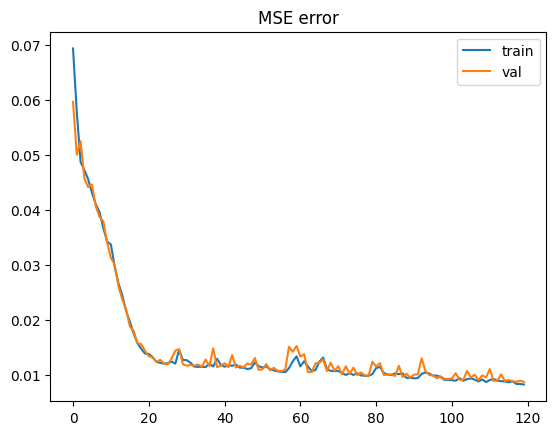

In [7]:
epochs = 120  #20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%10==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.093748726 MAE: 0.07441617


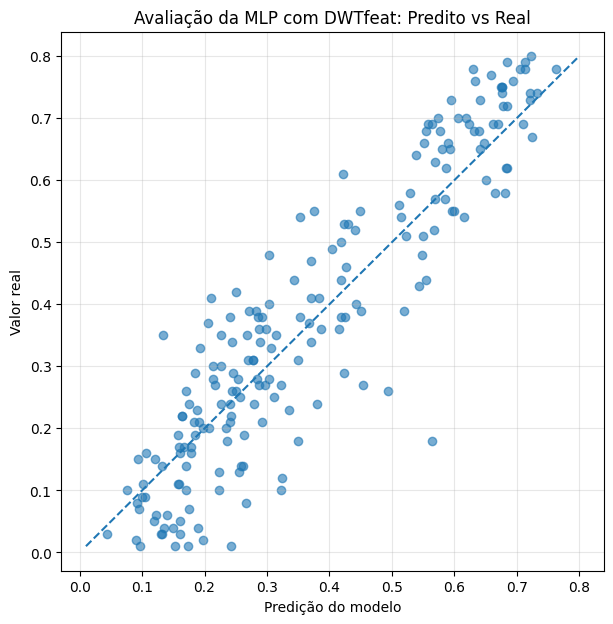

In [8]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, MAE
rmse = np.sqrt(np.mean((y_pred - yval)**2))
mae = np.mean(np.abs((y_pred - yval)))
print("RMSE:", rmse, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da MLP com DWTfeat: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# write_csv_file(y_pred.squeeze().detach().cpu().numpy())

### Fazendo PCA

In [11]:
train_df = pd.read_csv('data_train_DWTfeat.csv', sep="\t")
test_df = pd.read_csv('data_test_DWTfeat.csv', sep="\t")

In [12]:
pca = sklearn.decomposition.PCA(n_components=.95)
pca.fit(train_df.iloc[:,:-1])

,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [13]:
train_df_pca = pd.DataFrame(pca.transform(train_df.iloc[:,:-1]))
train_df_pca['y'] = train_df['y']
test_df_pca = pd.DataFrame(pca.transform(test_df))
# train_df_pca.to_csv("data_train_PCA.csv", sep="\t")
# test_df_pca.to_csv("data_test_PCA.csv", sep="\t")

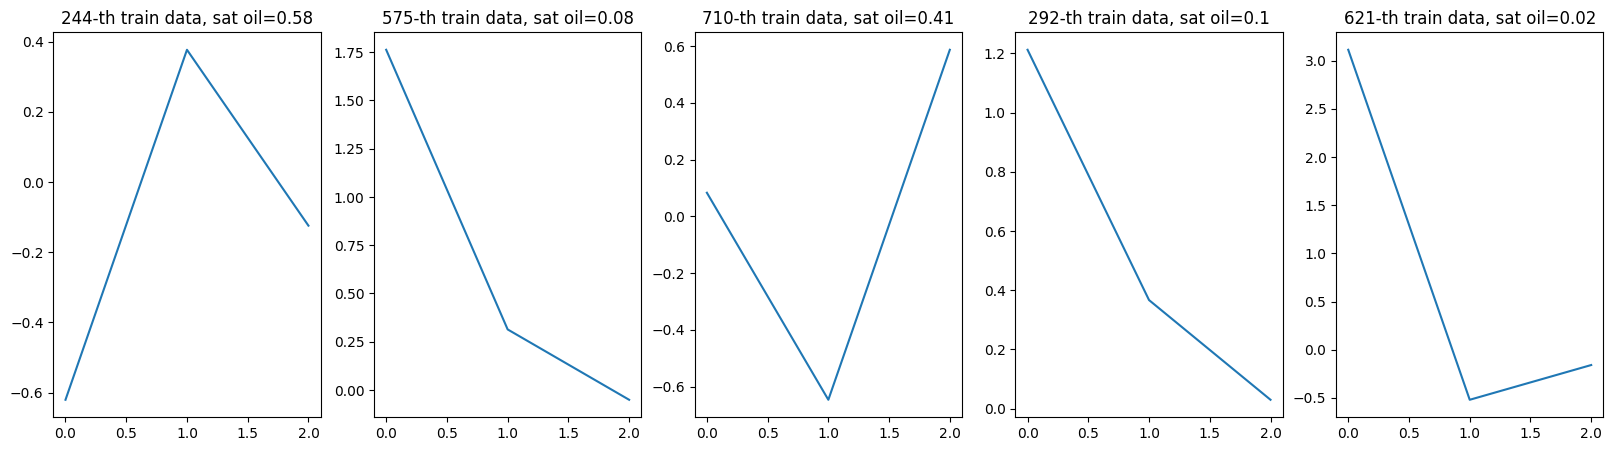

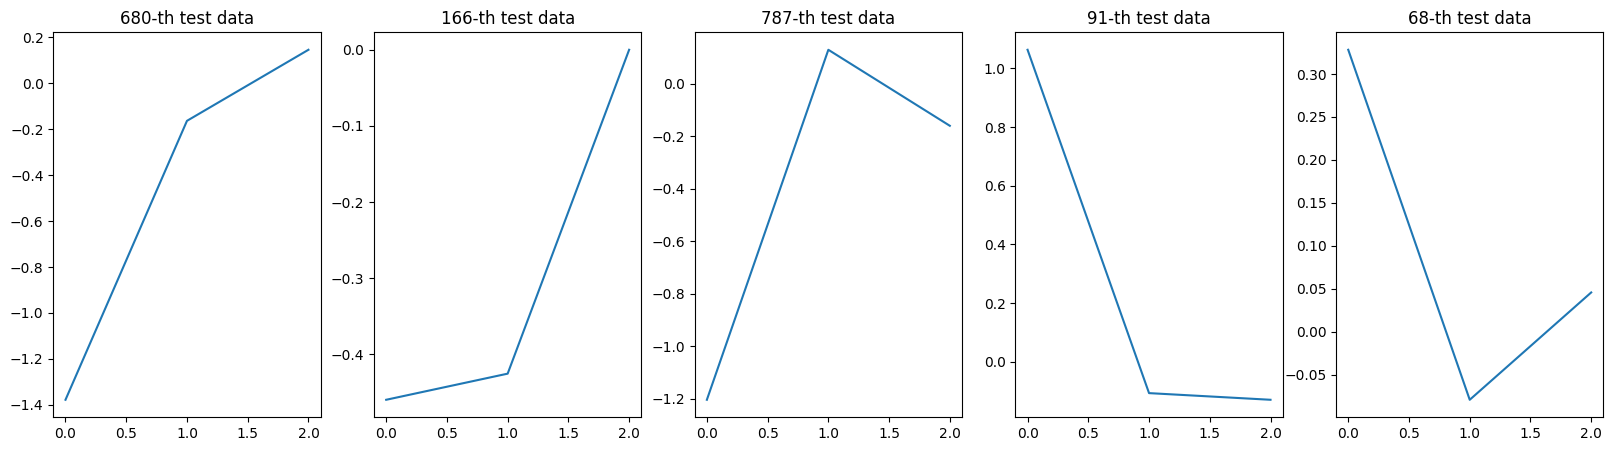

In [14]:
'''Plot graph of test and train after PCA'''
fig, ax = plt.subplots(1,5, figsize=(20,5))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(train_df_pca.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th train data, sat oil={train_df_pca.iloc[j,-1]}")
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,5))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(test_df_pca.loc[j].values)
    ax[i].set_title(f"{j}-th test data")
plt.show();

In [15]:
X = torch.Tensor(np.array(train_df_pca.drop('y',axis=1)))
y = torch.Tensor(np.array(train_df_pca['y']).reshape(-1,1))

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [16]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.051955 | Val MSE: 0.028285
Epoch 05 | Train MSE: 0.013229 | Val MSE: 0.011354
Epoch 10 | Train MSE: 0.011714 | Val MSE: 0.010394
Epoch 15 | Train MSE: 0.011377 | Val MSE: 0.010221
Epoch 20 | Train MSE: 0.011315 | Val MSE: 0.010249
Epoch 25 | Train MSE: 0.011297 | Val MSE: 0.010381
Epoch 30 | Train MSE: 0.011238 | Val MSE: 0.010240
Epoch 35 | Train MSE: 0.011338 | Val MSE: 0.009879
Epoch 40 | Train MSE: 0.011188 | Val MSE: 0.010308
Epoch 45 | Train MSE: 0.011086 | Val MSE: 0.010135
Epoch 50 | Train MSE: 0.011039 | Val MSE: 0.010759
Epoch 55 | Train MSE: 0.011053 | Val MSE: 0.010159
Epoch 60 | Train MSE: 0.010921 | Val MSE: 0.010293
Epoch 65 | Train MSE: 0.010962 | Val MSE: 0.010316
Epoch 70 | Train MSE: 0.010936 | Val MSE: 0.010214


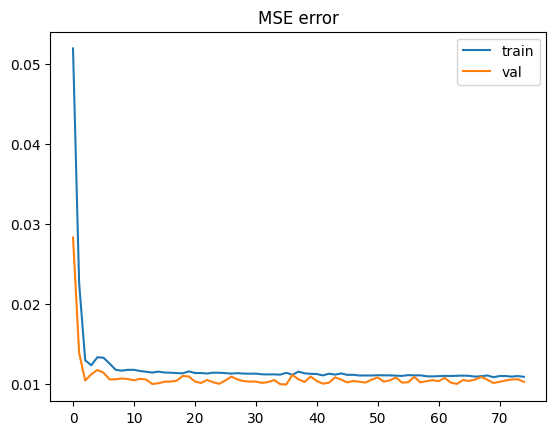

In [17]:
epochs = 75
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.100953765 MAE: 0.07784857


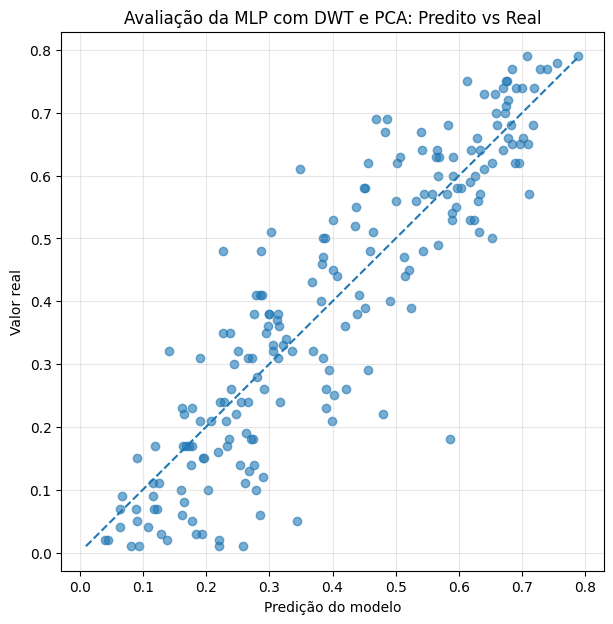

In [18]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, MAE
rmse = np.sqrt(np.mean((y_pred - yval)**2))
mae = np.mean(np.abs((y_pred - yval)))
print("RMSE:", rmse, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da MLP com DWT e PCA: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
Xtest = torch.Tensor(np.array(test_df_pca))
model.eval()
with torch.no_grad():
    ytest_pred = model(Xtest).squeeze().detach().cpu().numpy()

write_csv_file(ytest_pred)

,CPMG,%
0,CPMG_000.csv,0.302651
1,CPMG_001.csv,0.701934
2,CPMG_002.csv,0.180829
3,CPMG_003.csv,0.310258
4,CPMG_004.csv,0.087673
...,...,...
995,CPMG_995.csv,0.317961
996,CPMG_996.csv,0.721957
997,CPMG_997.csv,0.197669
998,CPMG_998.csv,0.218721


Agora com CatBoost

In [ ]:
%pip install catboost

## Catboost: training setup

In [23]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

X = np.array(train_df.iloc[:,:-1])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

model = CatBoostRegressor()
model.fit(Xtrain,ytrain, verbose=0, eval_set=(Xval,yval))

[(1000, 45), (1000,), (800, 45), (200, 45), (800,), (200,)]


RMSE: 0.09703071510543468 R²: 0.8295927498350757 MAE: 0.07630549340835531


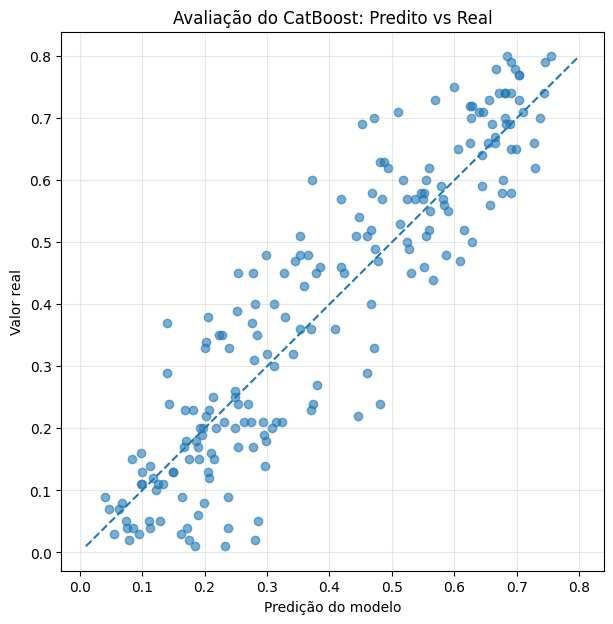

In [24]:
y_pred = model.predict(Xval)

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1 - mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação do CatBoost: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

Agora CatBoost no DWTfeat pós-PCA

In [25]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

X = np.array(train_df.iloc[:,:-1])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

model = CatBoostRegressor()
model.fit(Xtrain,ytrain, verbose=0, eval_set=(Xval,yval))

[(1000, 45), (1000,), (800, 45), (200, 45), (800,), (200,)]


RMSE: 0.09365483724113742 R²: 0.8355114195970924 MAE: 0.07150510676459187


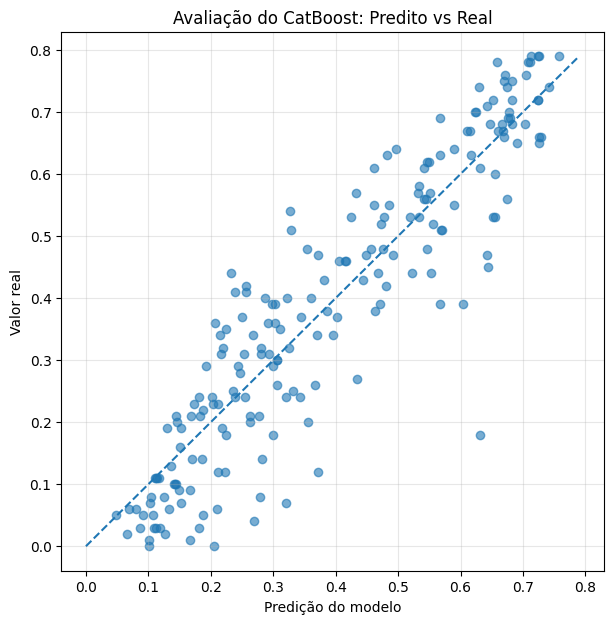

In [26]:
y_pred = model.predict(Xval)

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1 - mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação do CatBoost: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
Xtest = np.array(short_test_df.iloc[:,:-1])
write_csv_file(model.predict(Xtest))

## Agora uma CNN, por favor

In [27]:
train_df = pd.read_csv('data_train_DWTfeat.csv', sep="\t")
test_df = pd.read_csv('data_test_DWTfeat.csv', sep="\t")

In [28]:
X = torch.Tensor(np.array(train_df)[:,:-1]).unsqueeze(1)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1))

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [31]:
model = nn.Sequential(
    nn.Conv1d(1,4,5),
    nn.ReLU(),
    nn.MaxPool1d(2),

    nn.Conv1d(4,16,5),
    nn.ReLU(),
    nn.MaxPool1d(2),

    nn.Conv1d(16,4,5),
    nn.ReLU(),
    nn.MaxPool1d(2),
    
    nn.Flatten(),
    nn.Linear(8,64),
    nn.ReLU(),

    nn.Linear(64,16),
    nn.ReLU(),
        
    nn.Linear(16,1),
    nn.Sigmoid()
)

#to get the size right in the linear layer
# x = torch.randn(1000, 1, 2201)
# out = model(X)
# print(out.shape)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 04 | Train MSE: 0.068035 | Val MSE: 0.070142
Epoch 09 | Train MSE: 0.055502 | Val MSE: 0.050835
Epoch 14 | Train MSE: 0.051597 | Val MSE: 0.046088
Epoch 19 | Train MSE: 0.048710 | Val MSE: 0.042892
Epoch 24 | Train MSE: 0.041503 | Val MSE: 0.036344
Epoch 29 | Train MSE: 0.028163 | Val MSE: 0.024127
Epoch 34 | Train MSE: 0.016127 | Val MSE: 0.014275
Epoch 39 | Train MSE: 0.013675 | Val MSE: 0.013625
Epoch 44 | Train MSE: 0.013322 | Val MSE: 0.012883
Epoch 49 | Train MSE: 0.013089 | Val MSE: 0.012489
Epoch 54 | Train MSE: 0.012676 | Val MSE: 0.012295
Epoch 59 | Train MSE: 0.012375 | Val MSE: 0.012176
Epoch 64 | Train MSE: 0.012316 | Val MSE: 0.011685
Epoch 69 | Train MSE: 0.012048 | Val MSE: 0.011531
Epoch 74 | Train MSE: 0.011711 | Val MSE: 0.011320
Epoch 79 | Train MSE: 0.011733 | Val MSE: 0.011048
Epoch 84 | Train MSE: 0.011650 | Val MSE: 0.010851
Epoch 89 | Train MSE: 0.011326 | Val MSE: 0.010783
Epoch 94 | Train MSE: 0.011820 | Val MSE: 0.010457
Epoch 99 | Train MSE: 0.011209 

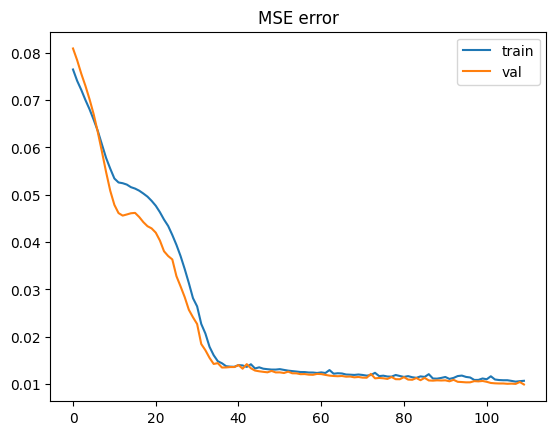

In [32]:
epochs = 110
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if (epoch+1)%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.0997151 R²: 0.7878434 MAE: 0.080696315


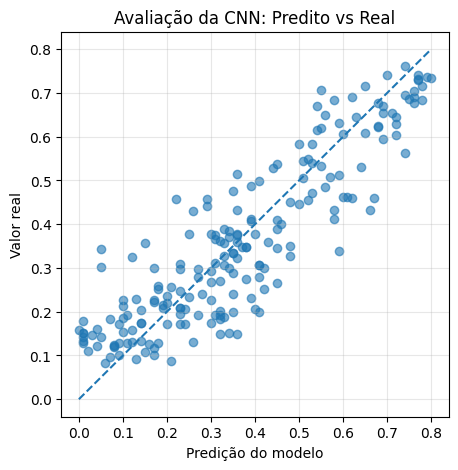

In [34]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1 - mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da CNN: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

## RNN: GRU

In [ ]:
train_df = pd.read_csv('data_train_DWTfeat.csv', sep="\t")
test_df = pd.read_csv('data_test_DWTfeat.csv', sep="\t")

In [ ]:
X = torch.Tensor(np.array(train_df)[:,:-1]).unsqueeze(2)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1))

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
X.shape

In [ ]:
hidden_size = 16
gru = nn.GRU(input_size=1, hidden_size=hidden_size, num_layers=2, batch_first=True)
head = nn.Linear(hidden_size, 1)   # prediction head

# combine params from both "submodules"
optimizer = torch.optim.Adam(list(gru.parameters()) + list(head.parameters()), lr=1e-3)
criterion = nn.MSELoss()

In [ ]:
# ----- training loop -----
gru.train(); head.train()
loss_history = []
for epoch in range(10):
    train_loss = 0.0
    for xb, yb in train_loader:
        # forward (manual “forward”)
        out, h = gru(xb)               # out: (B, T, H), h: (1, B, H)
        feat = out[:, -1, :]           # OR: h[-1]  (both are (B, H))
        pred = torch.sigmoid(head(feat))  # keep in [0,1]

        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        
    loss_history.append(train_loss/len(train_loader.dataset))
    print(f"epoch {epoch+1:02d} | train MSE: {train_loss/len(train_loader.dataset):.6f}")
plt.plot(loss_history);

In [ ]:
# ----- inference -----
gru.eval(); head.eval()
val_loss = 0
with torch.no_grad():
    for xb, yb in val_loader:
        out, h = gru(xb)
        feat = out[:, -1, :]
        y_pred = torch.sigmoid(head(feat))
        val_loss += criterion(y_pred, yb).item() * xb.size(0)
val_loss /= len(val_loader.dataset)

# RMSE, MAE
rmse = np.sqrt(np.mean((y_pred.squeeze().detach().cpu().numpy() - yval.reshape(-1,1))**2))
mae = np.mean(np.abs((y_pred.squeeze().detach().cpu().numpy() - yval.reshape(-1,1))))
print("RMSE:", rmse, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da GRU (RNN): Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

Horrível, algo deu errado aqui

## Random Forest

In [35]:
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.model_selection import train_test_split

X = np.array(train_df.iloc[:,:-1])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

[(1000, 45), (1000,), (800, 45), (200, 45), (800,), (200,)]


In [36]:
model = RFR(n_estimators=100, criterion='squared_error')
model.fit(Xtrain, ytrain)
y_pred, y_tr_pred = model.predict(Xval), model.predict(Xtrain)

RMSE: 0.08639940972020584 R²: 0.8651183866153698 MAE: 0.06979899999999999


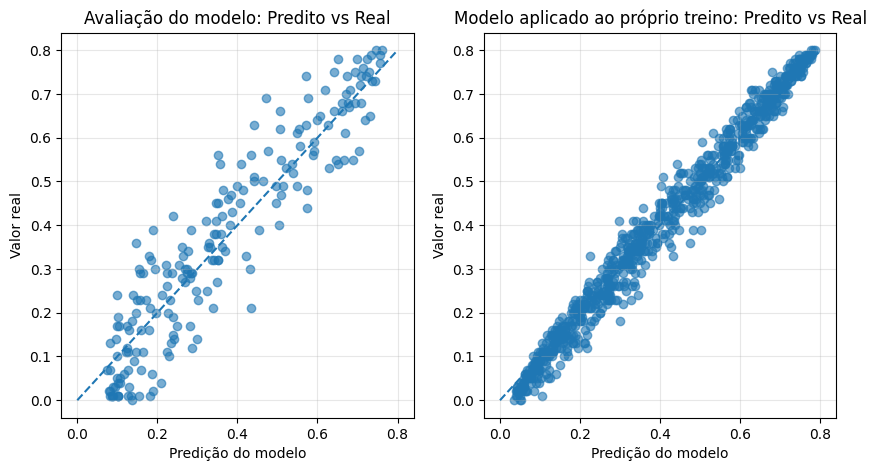

In [37]:
# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1 - mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
fig, (ax0,ax1) = plt.subplots(1,2, figsize=(10, 5))
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())

ax0.scatter(y_pred, yval, alpha=0.6)
ax0.plot([min_val, max_val], [min_val, max_val], '--')
ax0.set_xlabel("Predição do modelo")
ax0.set_ylabel("Valor real")
ax0.set_title("Avaliação do modelo: Predito vs Real")
ax0.grid(True, alpha=0.3)

ax1.scatter(y_tr_pred, ytrain, alpha=0.6)
ax1.plot([min_val, max_val], [min_val, max_val], '--')
ax1.set_xlabel("Predição do modelo")
ax1.set_ylabel("Valor real")
ax1.set_title("Modelo aplicado ao próprio treino: Predito vs Real")
ax1.grid(True, alpha=0.3)

plt.show()

Resultado fraco

RandomForestRegressor em cima do PCA das DWTfeatures

In [38]:
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.model_selection import train_test_split

X = np.array(train_df_pca.iloc[:,:-1])
y = np.array(train_df_pca['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

[(1000, 3), (1000,), (800, 3), (200, 3), (800,), (200,)]


In [39]:
model = RFR(n_estimators=100, criterion='squared_error')
model.fit(Xtrain, ytrain)
y_pred, y_tr_pred = model.predict(Xval), model.predict(Xtrain)

RMSE: 0.11314147404908603 R²: 0.735888609140516 MAE: 0.09176550000000003


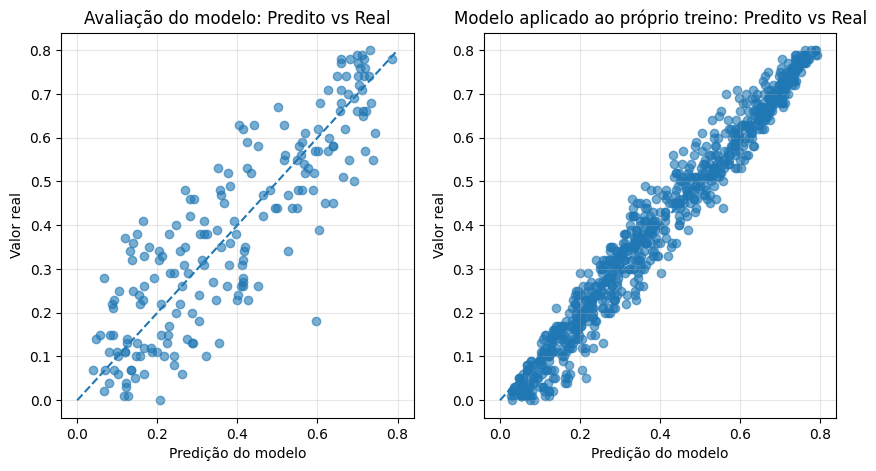

In [40]:
# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1 - mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
fig, (ax0,ax1) = plt.subplots(1,2, figsize=(10, 5))
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())

ax0.scatter(y_pred, yval, alpha=0.6)
ax0.plot([min_val, max_val], [min_val, max_val], '--')
ax0.set_xlabel("Predição do modelo")
ax0.set_ylabel("Valor real")
ax0.set_title("Avaliação do modelo: Predito vs Real")
ax0.grid(True, alpha=0.3)

ax1.scatter(y_tr_pred, ytrain, alpha=0.6)
ax1.plot([min_val, max_val], [min_val, max_val], '--')
ax1.set_xlabel("Predição do modelo")
ax1.set_ylabel("Valor real")
ax1.set_title("Modelo aplicado ao próprio treino: Predito vs Real")
ax1.grid(True, alpha=0.3)

plt.show()